# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [20]:
# Please, enter your name and RA number in the lines below:
print("Student 1", "Caio Azevedo Dal Porto", "256709")
print("Student 2", "Vinicius Leme Soares", "260727")

Student 1 Caio Azevedo Dal Porto 256709
Student 2 Vinicius Leme Soares 260727


---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [21]:
from typing import Any

from numpy.typing import NDArray
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
from torch import optim

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility.
# Do not tune this number
# Re-run the notebook from the beginning before submitting.
seed = 42
torch.random.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [22]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell

def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


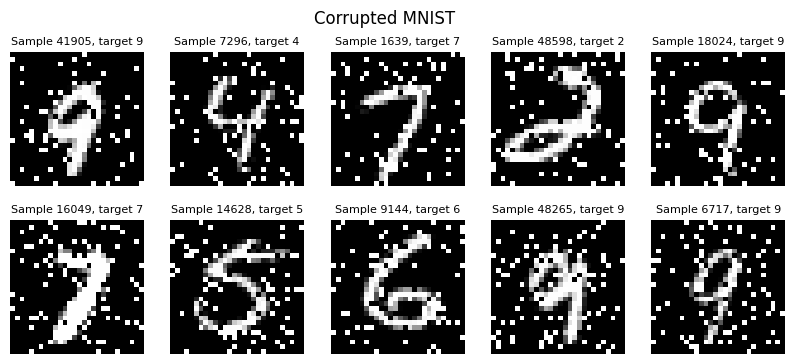

In [23]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

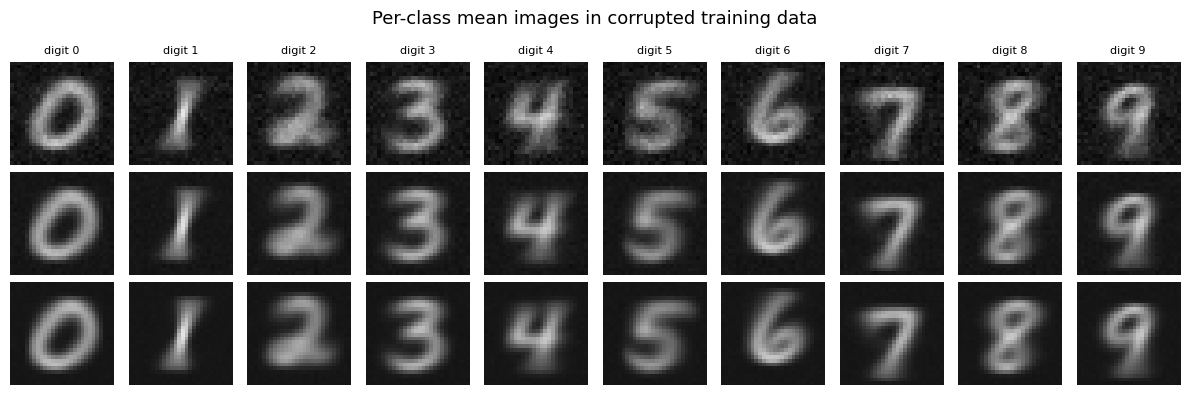

In [24]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        mean_img = X[mask].mean(axis=0)
        axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)

plt.suptitle("Per-class mean images in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

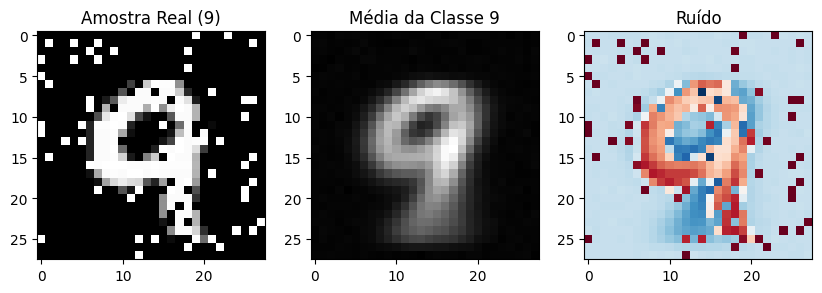

In [25]:
# Investigando se o ruído é "estático" ou aleatório por pixel
def check_noise_structure(X, y):
    plt.figure(figsize=(10, 4))
    
    # Pegando um dígito aleatório e a média da classe dele
    idx = random.randint(0, len(X) - 1)
    digit = y[idx]
    mean_img = X[y == digit].mean(axis=0)
    
    plt.subplot(1, 3, 1)
    plt.title(f"Amostra Real ({digit})")
    plt.imshow(X[idx], cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title(f"Média da Classe {digit}")
    plt.imshow(mean_img, cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("Ruído")
    plt.imshow(X[idx] - mean_img, cmap='RdBu_r')
    plt.show()

check_noise_structure(X_full, y_full)

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.

Descrição da Corrupção: A imagem mostra um ruído de impulso estruturado (blocos brancos). Pela visualização da "Média da Classe", vemos que ele é aleatório por amostra, pois o fundo da média fica limpo (os blocos não se acumulam no mesmo lugar).

Data Regimes: No regime Scarce (1.000 amostras), o perigo é o modelo "decorar" a posição de um bloco específico. Se em 10 imagens do número '5' houver um bloco no mesmo canto por azar, o modelo vai achar que bloco no canto indica número 5.

Hipótese: No Full-data, com 60k imagens, o modelo vai ver tanto bloco em tanto lugar diferente que vai aprender a ignorá-los como "fundo variável".

No Test_clean, o modelo Scarce vai ter o pior desempenho porque ele "viciou" em procurar esses blocos que não existem nas imagens limpas.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [26]:
from sklearn.preprocessing import StandardScaler

data_regimes_processed = {}
scalers = {}

def preprocess_regime(X, name):
    # (N, 28, 28) -> (N, 784)
    X_flat = X.reshape(X.shape[0], -1).astype(np.float32)
    
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flat)
    
    return X_scaled, scaler

In [27]:
X_full_proc, scalers["Full"] = preprocess_regime(X_full, "Full")
X_partial_proc, scalers["Partial"] = preprocess_regime(X_partial, "Partial")
X_scarce_proc, scalers["Scarce"] = preprocess_regime(X_scarce, "Scarce")

data_regimes_processed = {
    "Full": (X_full_proc, y_full),
    "Partial": (X_partial_proc, y_partial),
    "Scarce": (X_scarce_proc, y_scarce)
}

print("Shapes após pré-processamento:")
for name, (X, y) in data_regimes_processed.items():
    print(f"{name}: {X.shape}")

Shapes após pré-processamento:
Full: (60000, 784)
Partial: (10000, 784)
Scarce: (1000, 784)


> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

Escolheu-se o StandardScaler (Z-score normalization). Como vimos que a corrupção gera blocos brancos "extremos", padronizar os dados ajuda a diminuir o impacto desses outliers e faz com que o gradiente não exploda ou demore demais pra convergir.

Essa escolha é justificada pela escala e prevenção de data leakage:
- Escala: Modelos lineares com Softmax são bem sensíveis à escala. Deixar tudo na mesma ordem de grandeza ajuda o SGD a encontrar o mínimo global de forma mais estável.
- Prevenção de Data Leakage: Usa-se o fit do scaler separadamente em cada regime de treino. Isso garante que as estatísticas (média e desvio) venham apenas das imagens que o modelo "conhece", sem vazar o que vem nos conjuntos de teste. Se usasse a média do dataset inteiro, o modelo teria estatísticas das imagens de teste antes da hora, o que invalidaria os resultados.

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.

In [28]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 28x28 pixels = 784 entradas -> 10 classes de saída
        self.linear = nn.Linear(784, 10)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()

def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    losses = []
    
    for i in range(n_iter):
        logits = model(X)
        
        # Log Probs
        log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)
        # Cross-Entropy 
        loss_ce = -log_probs[range(len(y)), y].mean()
        
        # Lasso
        l1_penalty = l1 * torch.abs(model.linear.weight).sum()
        # Ridge
        l2_penalty = l2 * (model.linear.weight ** 2).sum()
        # Loss + l1 + l2
        total_loss = loss_ce + l1_penalty + l2_penalty
        
        # Backward 
        total_loss.backward()
        
        # Otimização SGD e Zeragem de Gradientes
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is not None:
                    # p = p - lr * grad
                    p.copy_(p - lr * p.grad)
                    p.grad.zero_()
        
        losses.append(total_loss.item())
        
    return losses

### 2.3 Baseline mode

**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

Treinando Baseline para o regime: Full...
Treinando Baseline para o regime: Partial...
Treinando Baseline para o regime: Scarce...


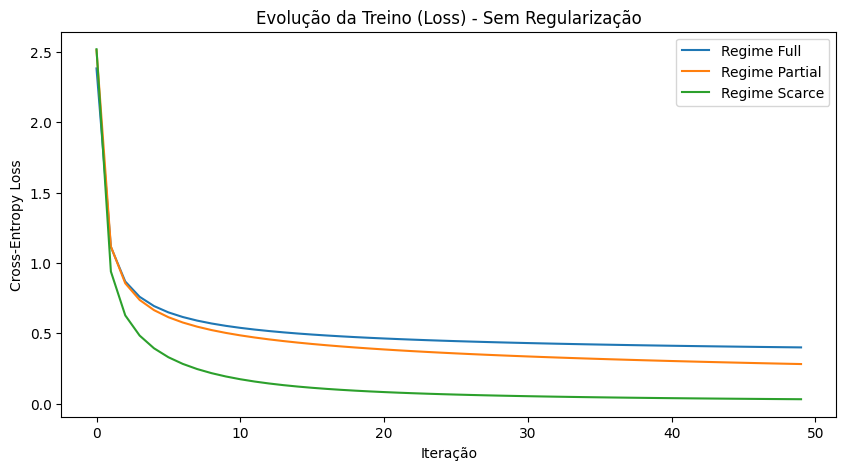

In [29]:
baseline_models = {}
baseline_losses = {}

n_iter = 50
lr = 0.5

for name, (X_np, y_np) in data_regimes_processed.items():
    print(f"Treinando Baseline para o regime: {name}...")
    
    # NumPy -> Tensores
    X_torch = torch.from_numpy(X_np).float()
    y_torch = torch.from_numpy(y_np).long()
    
    model = LinearModel()
    # Sem regularização
    losses = train(model, X_torch, y_torch, n_iter=n_iter, lr=lr, l1=0.0, l2=0.0)
    
    baseline_models[name] = model
    baseline_losses[name] = losses

# --- Visualização da Perda ---
plt.figure(figsize=(10, 5))
for name, losses in baseline_losses.items():
    plt.plot(losses, label=f"Regime {name}")
plt.title("Evolução da Treino (Loss) - Sem Regularização")
plt.xlabel("Iteração")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

In [30]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

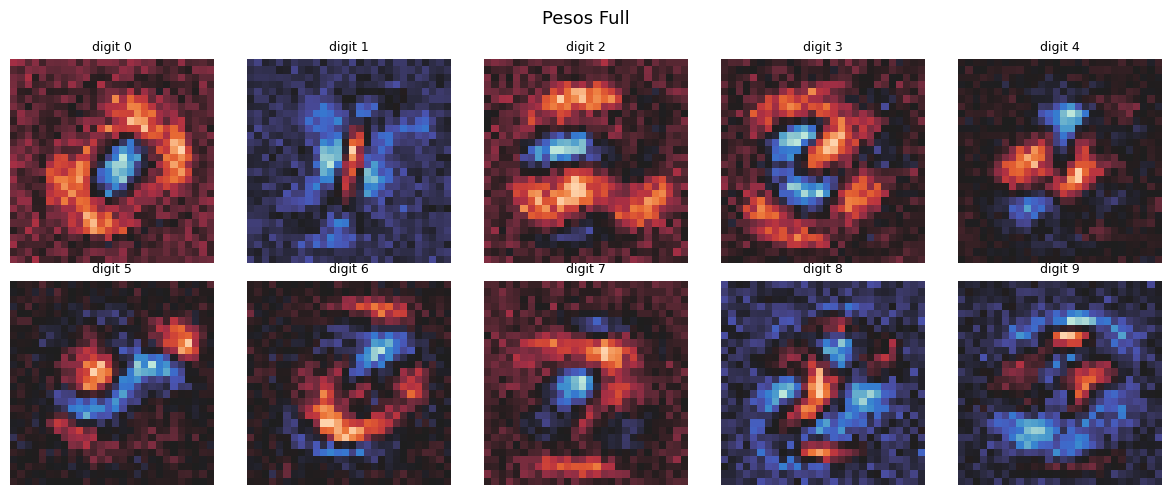

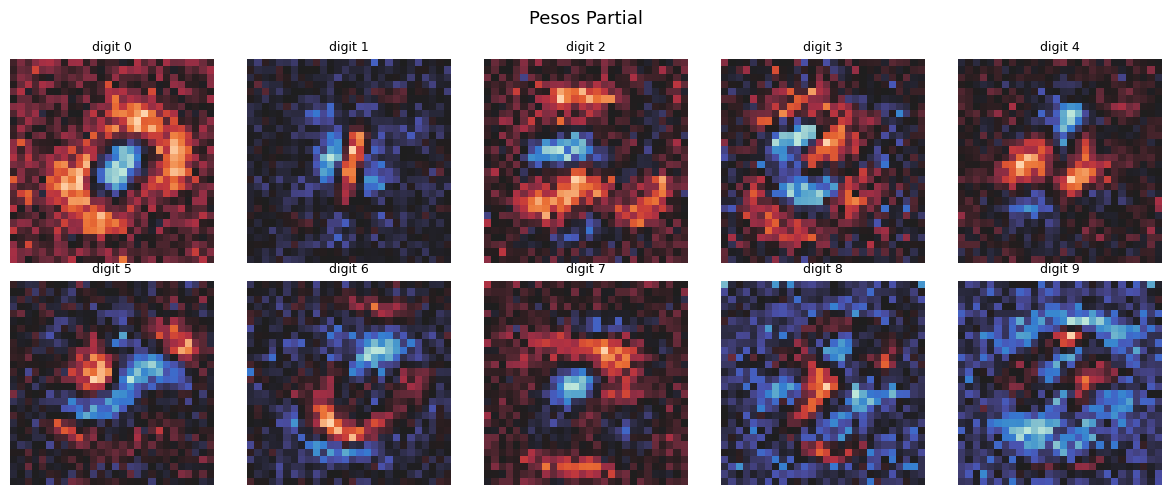

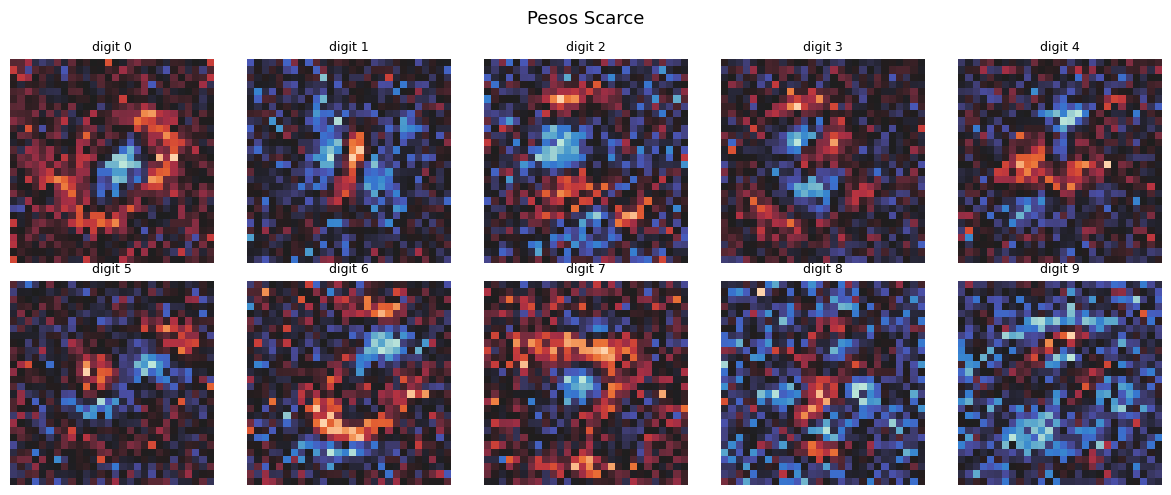

In [31]:
for name, model in baseline_models.items():
    weights = model.linear.weight.detach().numpy()
    plot_weights(weights, title=f"Pesos {name}")

> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

Os pesos funcionam como templates de busca. Quando o modelo recebe uma imagem, ele faz uma comparação pixel a pixel com esses mapas de calor para decidir a classe.

Modelo Full:
- É o que apresenta a maior relação sinal-ruído. Os formatos dos números são nítidos (ex: o círculo central azul no dígito 0 e o traço vertical no 1).
- Como a corrupção é aleatória por amostra, o grande volume de dados permitiu que o modelo "tirasse a média" das interferências. O resultado são pesos focados quase exclusivamente na morfologia real dos dígitos.

Modelo Partial:
- O sinal ainda é forte, mas o "fundo" dos pesos começa a ficar granulado.
- O modelo já consegue classificar bem, mas os templates não são tão "puros". Ele começa a dar importância para alguns pixels de ruído que se repetiram por coincidência no conjunto de 10k imagens.

Modelo Scarce:
- Os pesos são caóticos e fragmentados. É difícil reconhecer o dígito 8 ou o 5, por exemplo.
- Com pouquíssimos dados, o modelo sofreu um overfitting agressivo. Em vez de aprender a forma geral do número, ele aprendeu as localizações específicas dos blocos de ruído que estavam presentes naquelas 1.000 imagens.

---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.


In [32]:
# Implement K-fold cross-validation with correct pre-processing

from sklearn.model_selection import StratifiedKFold

def cross_validate(X_raw, y, l1=0.0, l2=0.0, n_splits=5, n_iter=50, lr=0.5):
    """
    Realiza K-fold CV garantindo que o pré-processamento ocorra dentro do loop.
    X_raw deve ser o array NumPy original (N, 28, 28) antes do scaling.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    val_accuracies = []
    
    # Achatar as imagens de (N, 28, 28) para (N, 784)
    X_flat = X_raw.reshape(X_raw.shape[0], -1).astype(np.float32)
    
    for train_idx, val_idx in skf.split(X_flat, y):
        X_train_fold, X_val_fold = X_flat[train_idx], X_flat[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # PRÉ-PROCESSAMENTO CORRETO: fit apenas no treino do fold!
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # Converter para tensores PyTorch
        X_train_t = torch.from_numpy(X_train_scaled).float()
        y_train_t = torch.from_numpy(y_train_fold).long()
        X_val_t = torch.from_numpy(X_val_scaled).float()
        y_val_t = torch.from_numpy(y_val_fold).long()
        
        torch.manual_seed(42)
        
        # Treinar o modelo neste fold
        model = LinearModel()
        train(model, X_train_t, y_train_t, n_iter=n_iter, lr=lr, l1=l1, l2=l2)
        
        # Avaliar na validação
        with torch.no_grad():
            logits = model(X_val_t)
            acc = accuracy(logits, y_val_t)
            val_accuracies.append(acc)
            
    return np.mean(val_accuracies)

# --- Executando o Grid Search ---
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 2.0] # Valores comuns para varredura
best_params = {}

# Usando os dados brutos (X_full, X_partial, X_scarce) que declaramos na Parte 1
raw_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

for name, (X_raw, y_raw) in raw_regimes.items():
    print(f"\n--- Buscando melhor lambda para o regime: {name} ---")
    best_params[name] = {'L1': {'lambda': 0, 'acc': 0}, 'L2': {'lambda': 0, 'acc': 0}}
    
    # Busca L1
    for l in lambdas:
        acc = cross_validate(X_raw, y_raw, l1=l, l2=0.0)
        print(f"L1 (lambda={l}): Val Acc = {acc:.4f}")
        if acc > best_params[name]['L1']['acc']:
            best_params[name]['L1']['acc'] = acc
            best_params[name]['L1']['lambda'] = l
            
    # Busca L2
    for l in lambdas:
        acc = cross_validate(X_raw, y_raw, l1=0.0, l2=l)
        print(f"L2 (lambda={l}): Val Acc = {acc:.4f}")
        if acc > best_params[name]['L2']['acc']:
            best_params[name]['L2']['acc'] = acc
            best_params[name]['L2']['lambda'] = l

print("\nResumo dos melhores parâmetros encontrados:")
print(best_params)


--- Buscando melhor lambda para o regime: Scarce ---
L1 (lambda=0.0001): Val Acc = 0.7900
L1 (lambda=0.001): Val Acc = 0.8030
L1 (lambda=0.01): Val Acc = 0.8040
L1 (lambda=0.1): Val Acc = 0.4360
L1 (lambda=1.0): Val Acc = 0.2070
L1 (lambda=2.0): Val Acc = 0.4000
L2 (lambda=0.0001): Val Acc = 0.7900
L2 (lambda=0.001): Val Acc = 0.7900
L2 (lambda=0.01): Val Acc = 0.7890
L2 (lambda=0.1): Val Acc = 0.8010
L2 (lambda=1.0): Val Acc = 0.4850
L2 (lambda=2.0): Val Acc = 0.0030

--- Buscando melhor lambda para o regime: Partial ---
L1 (lambda=0.0001): Val Acc = 0.8422
L1 (lambda=0.001): Val Acc = 0.8505
L1 (lambda=0.01): Val Acc = 0.8244
L1 (lambda=0.1): Val Acc = 0.4216
L1 (lambda=1.0): Val Acc = 0.2556
L1 (lambda=2.0): Val Acc = 0.4865
L2 (lambda=0.0001): Val Acc = 0.8411
L2 (lambda=0.001): Val Acc = 0.8415
L2 (lambda=0.01): Val Acc = 0.8461
L2 (lambda=0.1): Val Acc = 0.8446
L2 (lambda=1.0): Val Acc = 0.5844
L2 (lambda=2.0): Val Acc = 0.0036

--- Buscando melhor lambda para o regime: Full ---

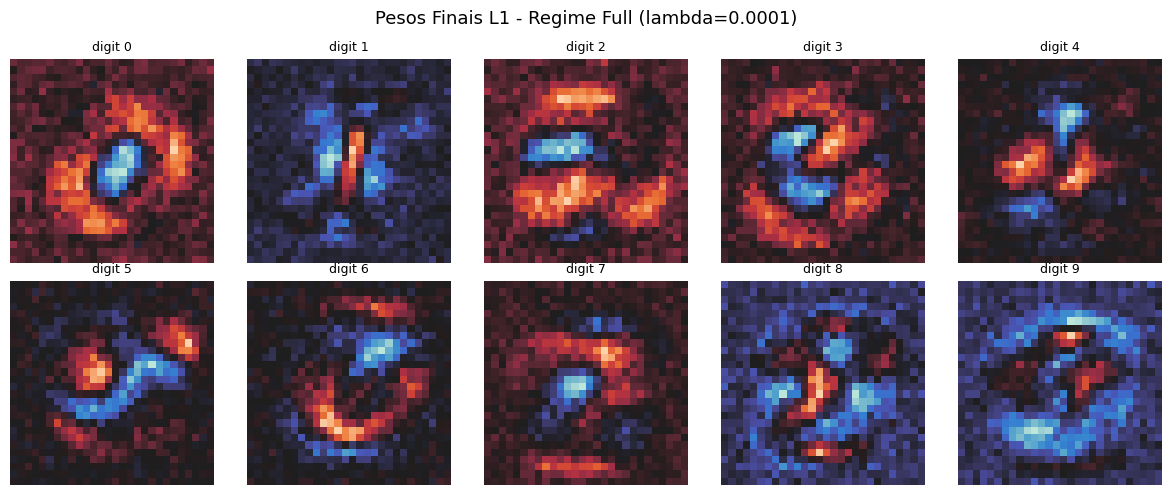

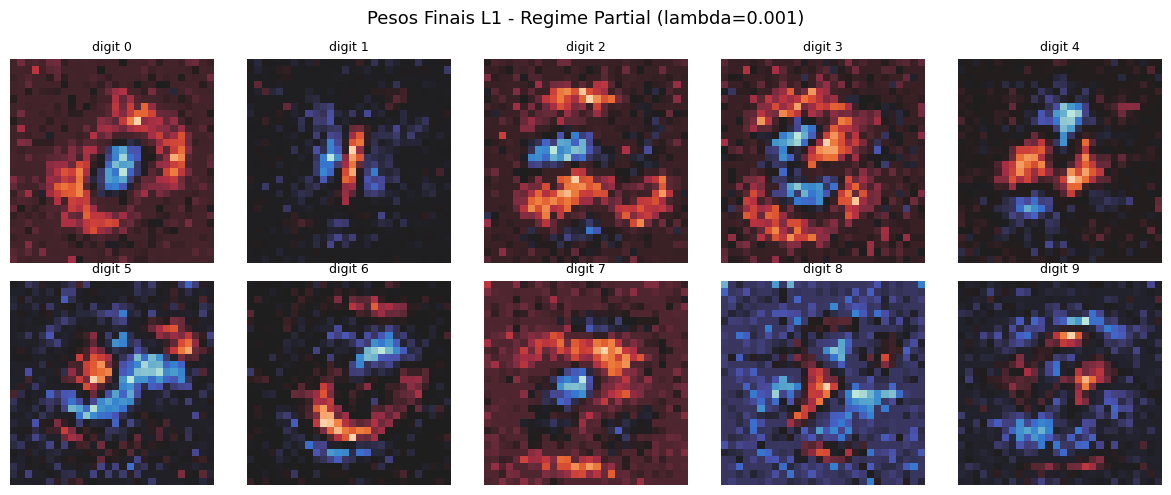

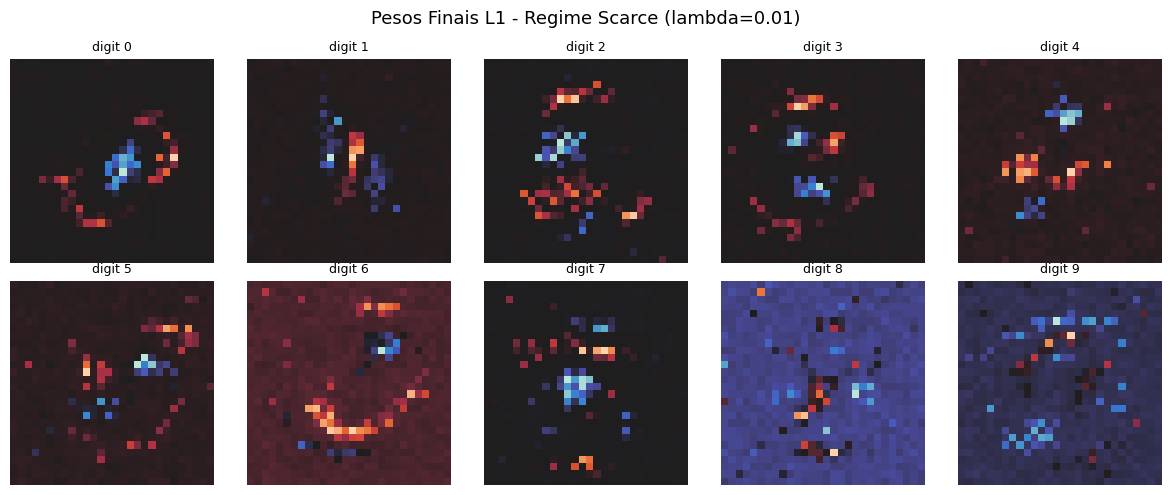

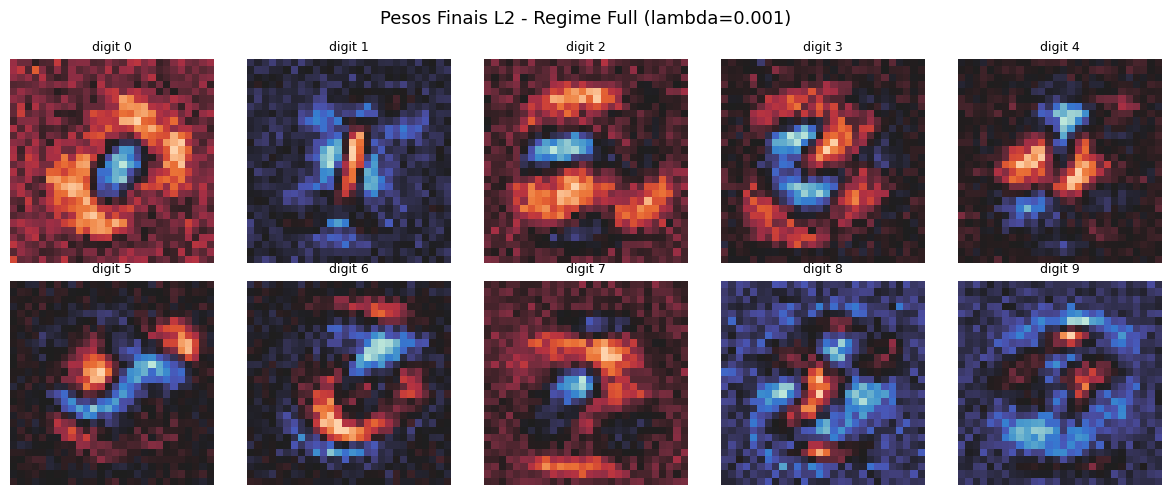

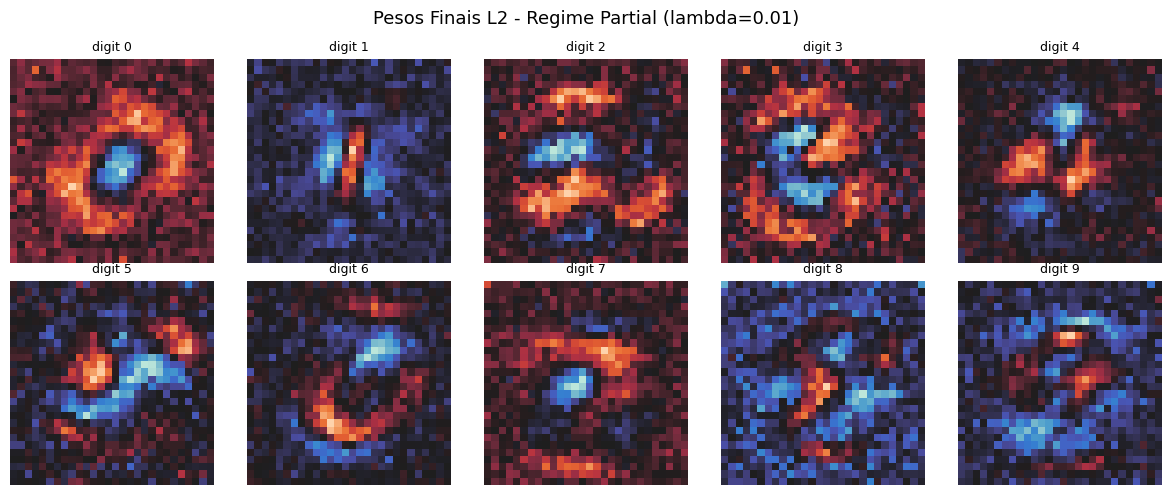

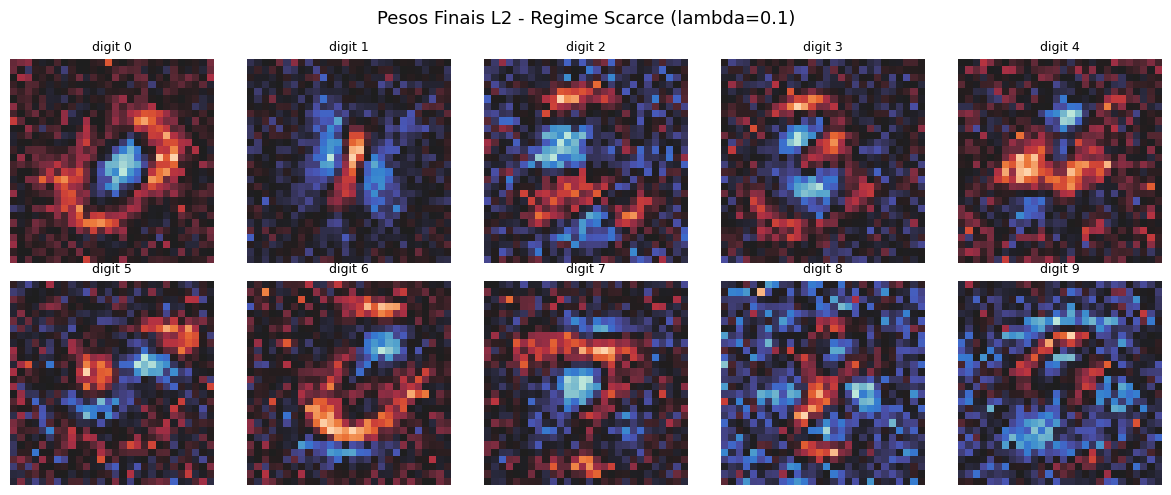

In [33]:
final_models = {'L1': {}, 'L2': {}}

# Usando os dados já processados da Parte 1 (data_regimes_processed)
for name, (X_np, y_np) in data_regimes_processed.items():
    X_torch = torch.from_numpy(X_np).float()
    y_torch = torch.from_numpy(y_np).long()
    
    # --- Modelo Final L1 ---
    best_l1 = best_params[name]['L1']['lambda']
    model_l1 = LinearModel()
    train(model_l1, X_torch, y_torch, n_iter=50, lr=0.5, l1=best_l1, l2=0.0)
    final_models['L1'][name] = model_l1
    
    # --- Modelo Final L2 ---
    best_l2 = best_params[name]['L2']['lambda']
    model_l2 = LinearModel()
    train(model_l2, X_torch, y_torch, n_iter=50, lr=0.5, l1=0.0, l2=best_l2)
    final_models['L2'][name] = model_l2

# --- Visualizando os Pesos Finais ---
for reg_type in ['L1', 'L2']:
    for name in final_models[reg_type].keys():
        weights = final_models[reg_type][name].linear.weight.detach().numpy()
        plot_weights(weights, title=f"Pesos Finais {reg_type} - Regime {name} (lambda={best_params[name][reg_type]['lambda']})")

> **Question 4**
>
> (a) As $\lambda$ increases for L2 regularization, how does CV accuracy change on each data regime?
> Are there clear optima, or does accuracy plateau?
>
> (b) Compare the weight images of the CV-selected L2 model, the CV-selected L1 model, and the unregularized baseline. What differences do you observe in terms of structure and sparsity?
>
> (c) Connect the weight images to the corruption structure identified in Part 1. Does the CV-selected model appear to have suppressed the corruption pattern, amplified it, or is it ambiguous from weights alone?
>
> (d) **Predict**, based on what you see in the weights and CV curves, which of your three CV-selected models (none / L2 / L1) you expect will perform best on clean, uncorrupted images — and which worst. Justify your prediction before seeing any test results.


(a) Quando aumentamos o λ na regularização L2, notamos que a acurácia de validação não se comporta da mesma forma em todos os regimes. No regime Scarce, há um ótimo claro: a acurácia começa em 79.0%, atinge um pico de pouco mais de 80% em λ=0.1 e depois despenca. Já nos regimes Partial e Full, a acurácia começa muito próxima do seu valor máximo em penalizações muito baixas (λ=0.0001) e mantém um platô estável até λ=0.01, caindo drasticamente se aumentarmos para λ=1.0. Resumindo: existe um ponto ótimo claro para o cenário de poucos dados, enquanto nos cenários com muitos dados a acurácia apenas entra em platô nos valores baixos e afunda se "pesarmos demais a mão" na regularização, causando underfitting.

(b) Focando na análise do regime Scarce, percebemos que a diferença de estrutura e esparsidade entre eles é bem considerável. No modelo Baseline (sem regularização), principalmente com poucos dados, os mapas de pesos são mais caóticos; o modelo dá importância (pesos altos) para vários pontos aleatórios no fundo da imagem. Já no modelo selecionado com L1, observamos uma esparsidade extrema: o fundo fica praticamente todo preto (pesos zerados), sobrando apenas um "esqueleto" com os pixels que realmente importam para o desenho do dígito. O L2 tem um comportamento intermediário: ele não zera os pesos do fundo, mas os "borra" e suaviza, impedindo que pixels isolados ganhem valores extremos. O L1 corta o excesso, o L2 apenas o dilui.

(c) Na Parte 1, identificamos que a corrupção eram blocos brancos aleatórios que apareciam no fundo das imagens. Olhando os mapas de calor, fica claro que os modelos selecionados por CV (especialmente o L1) conseguiram suprimir esse padrão. Como o modelo com L1 zerou quase tudo ao redor do centro, ele basicamente aprendeu a ignorar as bordas onde esses blocos espúrios apareciam. No baseline de poucos dados, víamos exatamente o contrário: o modelo havia amplificado a corrupção, enchendo o fundo de "pontos cegos" vermelhos e azuis para tentar usar o ruído como regra de classificação.

(d) Nossa aposta é que o modelo L1 selecionado pelo CV será o que terá o melhor desempenho nas imagens limpas (test_clean), e o Baseline (sem regularização) será disparado o pior.
A justificativa para isso está nos pesos: o modelo Baseline sofreu overfitting e "viciou" em procurar os blocos brancos para decidir a classe. Como as imagens limpas não têm esses blocos, ele vai se perder completamente na hora de classificar. Por outro lado, como o L1 zerou os pesos das margens e aprendeu apenas o "esqueleto" morfológico do número, o fato do fundo estar limpo ou sujo importa muito pouco para ele. Esperamos que o L2 fique no meio-termo, melhor que o baseline, mas talvez um pouco mais sensível à mudança de distribuição que o L1, já que seus pesos de fundo não são perfeitamente nulos.

---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.

🎯 RESULTADOS NO TESTE CLEAN (Imagens Limpas / OOD)
|         |   Baseline (Sem Reg) |   L1 (Selecionado CV) |   L2 (Selecionado CV) |
|:--------|---------------------:|----------------------:|----------------------:|
| Scarce  |               0.8477 |                0.8349 |                0.8381 |
| Partial |               0.8914 |                0.8904 |                0.8881 |
| Full    |               0.8937 |                0.8938 |                0.8924 |


🎯 RESULTADOS NO TESTE CORRUPTED (Mesma Dist. do Treino)
|         |   Baseline (Sem Reg) |   L1 (Selecionado CV) |   L2 (Selecionado CV) |
|:--------|---------------------:|----------------------:|----------------------:|
| Scarce  |               0.8057 |                0.8097 |                0.8188 |
| Partial |               0.8631 |                0.8704 |                0.8634 |
| Full    |               0.8789 |                0.8803 |                0.8774 |


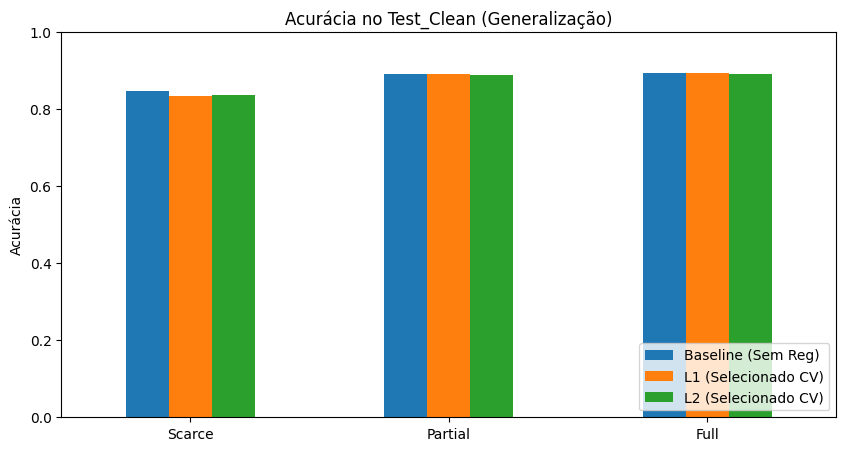

In [34]:
# --- Carregando os dados de teste ---
X_test_clean_raw = np.load("data/test/clean_images.npy")
y_test_clean = np.load("data/test/clean_labels.npy")

X_test_corr_raw = np.load("data/test/test_images.npy")
y_test_corr = np.load("data/test/test_labels.npy")

# Achatando as imagens (N, 28, 28) para (N, 784)
X_test_clean_flat = X_test_clean_raw.reshape(X_test_clean_raw.shape[0], -1).astype(np.float32)
X_test_corr_flat = X_test_corr_raw.reshape(X_test_corr_raw.shape[0], -1).astype(np.float32)

# Dicionários para armazenar os resultados
resultados_clean = {}
resultados_corr = {}

regimes = ["Scarce", "Partial", "Full"]

for name in regimes:
    # 1. Recuperamos o scaler ajustado APENAS no treino deste regime
    scaler = scalers[name]
    
    # 2. Aplicamos o transform nos dois conjuntos de teste
    X_clean_scaled = scaler.transform(X_test_clean_flat)
    X_corr_scaled = scaler.transform(X_test_corr_flat)
    
    # 3. Convertendo para Tensores
    X_clean_t = torch.from_numpy(X_clean_scaled).float()
    y_clean_t = torch.from_numpy(y_test_clean).long()
    
    X_corr_t = torch.from_numpy(X_corr_scaled).float()
    y_corr_t = torch.from_numpy(y_test_corr).long()
    
    resultados_clean[name] = {}
    resultados_corr[name] = {}
    
    # 4. Reunindo os modelos que selecionamos
    modelos_para_testar = {
        'Baseline (Sem Reg)': baseline_models[name],
        'L1 (Selecionado CV)': final_models['L1'][name],
        'L2 (Selecionado CV)': final_models['L2'][name]
    }
    
    # 5. Avaliando
    for model_name, model in modelos_para_testar.items():
        model.eval() # Modo de avaliação garante que não computaremos gradientes atoa
        with torch.no_grad():
            # Teste na base Limpa
            logits_clean = model(X_clean_t)
            acc_clean = accuracy(logits_clean, y_clean_t)
            resultados_clean[name][model_name] = acc_clean
            
            # Teste na base Corrompida (Distribuição igual ao treino)
            logits_corr = model(X_corr_t)
            acc_corr = accuracy(logits_corr, y_corr_t)
            resultados_corr[name][model_name] = acc_corr

# --- Formatando e Exibindo os Resultados ---
import pandas as pd

df_clean = pd.DataFrame(resultados_clean).T
df_corr = pd.DataFrame(resultados_corr).T

print("======================================================")
print("🎯 RESULTADOS NO TESTE CLEAN (Imagens Limpas / OOD)")
print("======================================================")
print(df_clean.to_markdown(floatfmt=".4f"))
print("\n")
print("======================================================")
print("🎯 RESULTADOS NO TESTE CORRUPTED (Mesma Dist. do Treino)")
print("======================================================")
print(df_corr.to_markdown(floatfmt=".4f"))

# Código opcional para gerar um gráfico de barras comparativo
df_clean.plot(kind='bar', figsize=(10, 5), title="Acurácia no Test_Clean (Generalização)")
plt.ylabel("Acurácia")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

Treinando modelos para construir as curvas (isso pode levar um minuto)...


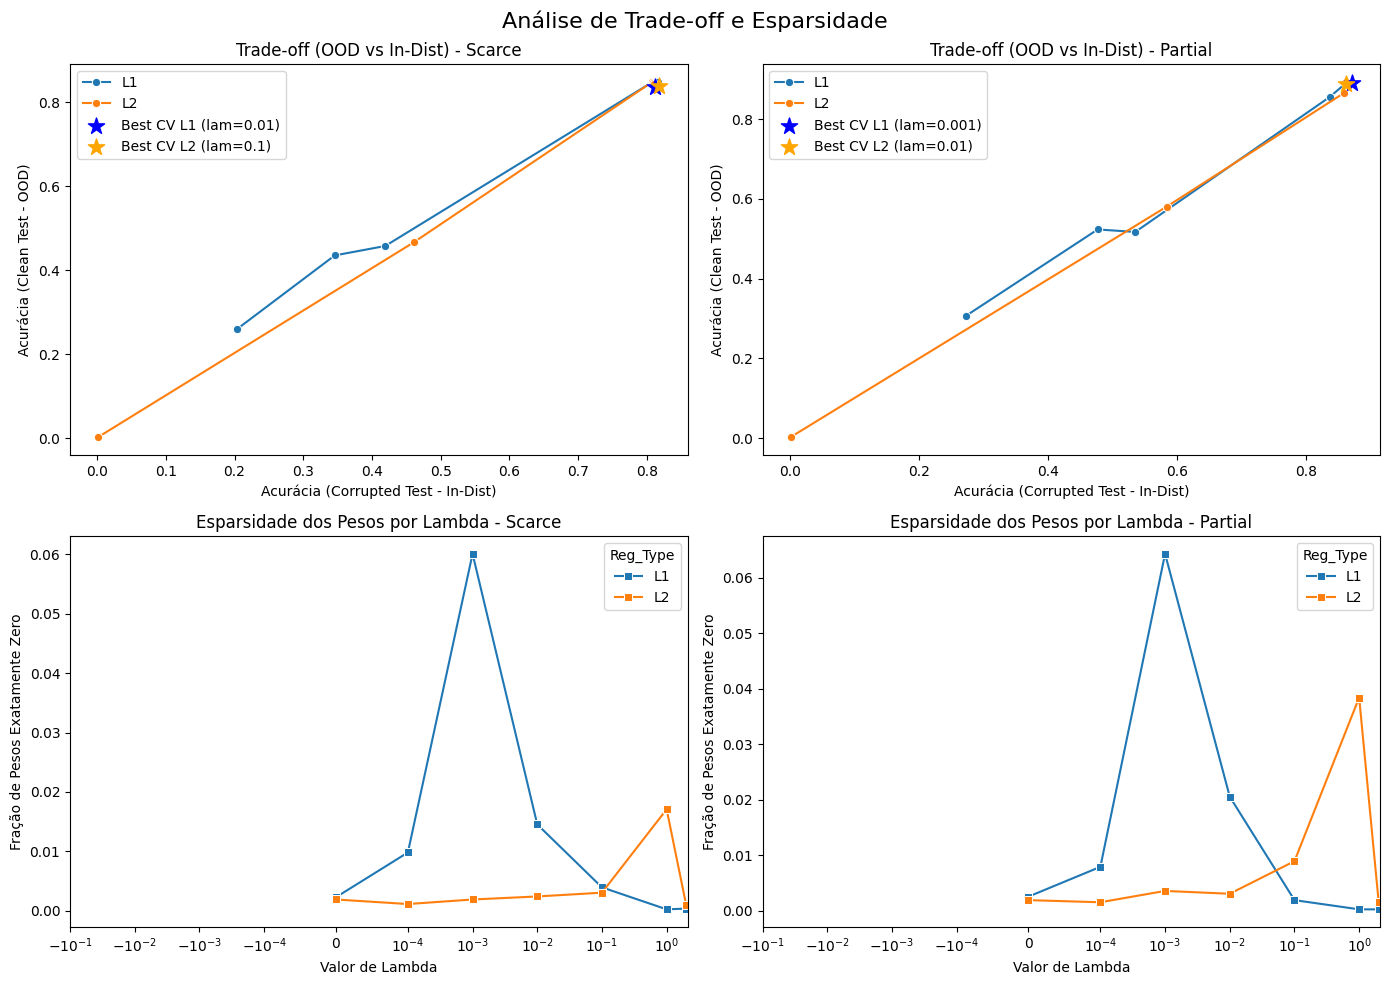

In [35]:
# Valores de lambda para varrer e construir a curva
lambdas_sweep = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 2.0]

resultados_sweep = []

# Vamos focar a visualização no regime "Scarce" e "Partial", que é onde
# os efeitos da regularização e do overfitting são mais extremos.
regimes_plot = ["Scarce", "Partial"]

print("Treinando modelos para construir as curvas (isso pode levar um minuto)...")

for name in regimes_plot:
    X_torch = torch.from_numpy(data_regimes_processed[name][0]).float()
    y_torch = torch.from_numpy(data_regimes_processed[name][1]).long()
    
    scaler = scalers[name]
    X_clean_t = torch.from_numpy(scaler.transform(X_test_clean_flat)).float()
    X_corr_t = torch.from_numpy(scaler.transform(X_test_corr_flat)).float()
    
    for reg_type in ['L1', 'L2']:
        for lam in lambdas_sweep:
            model = LinearModel()
            
            # Treino (se lam == 0.0, é o equivalente a baseline)
            l1_val = lam if reg_type == 'L1' else 0.0
            l2_val = lam if reg_type == 'L2' else 0.0
            
            train(model, X_torch, y_torch, n_iter=50, lr=0.5, l1=l1_val, l2=l2_val)
            
            model.eval()
            with torch.no_grad():
                acc_clean = accuracy(model(X_clean_t), y_clean_t)
                acc_corr = accuracy(model(X_corr_t), y_corr_t)
                
                # Calculando Esparsidade (fração de pesos quase zero)
                # Consideramos "zero" valores menores que 1e-4 em módulo
                pesos = model.linear.weight
                sparsity = (torch.abs(pesos) < 1e-4).float().mean().item()
                
            resultados_sweep.append({
                'Regime': name,
                'Reg_Type': reg_type,
                'Lambda': lam,
                'Acc_Clean': acc_clean,
                'Acc_Corr': acc_corr,
                'Sparsity': sparsity
            })

df_sweep = pd.DataFrame(resultados_sweep)

# --- PLOTAGENS ---
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análise de Trade-off e Esparsidade", fontsize=16)

for i, name in enumerate(regimes_plot):
    df_regime = df_sweep[df_sweep['Regime'] == name]
    
    # --- 1. Gráfico de Trade-off (Acc Corr vs Acc Clean) ---
    ax_trade = axs[0, i]
    sns.lineplot(data=df_regime, x='Acc_Corr', y='Acc_Clean', hue='Reg_Type', marker='o', ax=ax_trade)
    ax_trade.set_title(f"Trade-off (OOD vs In-Dist) - {name}")
    ax_trade.set_xlabel("Acurácia (Corrupted Test - In-Dist)")
    ax_trade.set_ylabel("Acurácia (Clean Test - OOD)")
    
    # Destacando os modelos selecionados por CV (da Parte 3)
    best_l1_lam = best_params[name]['L1']['lambda']
    best_l2_lam = best_params[name]['L2']['lambda']
    
    best_l1_row = df_regime[(df_regime['Reg_Type'] == 'L1') & (df_regime['Lambda'] == best_l1_lam)]
    best_l2_row = df_regime[(df_regime['Reg_Type'] == 'L2') & (df_regime['Lambda'] == best_l2_lam)]
    
    if not best_l1_row.empty:
        ax_trade.scatter(best_l1_row['Acc_Corr'], best_l1_row['Acc_Clean'], color='blue', s=150, marker='*', zorder=5, label=f'Best CV L1 (lam={best_l1_lam})')
    if not best_l2_row.empty:
        ax_trade.scatter(best_l2_row['Acc_Corr'], best_l2_row['Acc_Clean'], color='orange', s=150, marker='*', zorder=5, label=f'Best CV L2 (lam={best_l2_lam})')
    
    ax_trade.legend()

    # --- 2. Gráfico de Esparsidade vs Acc_Clean ---
    ax_spars = axs[1, i]
    sns.lineplot(data=df_regime, x='Lambda', y='Sparsity', hue='Reg_Type', marker='s', ax=ax_spars)
    ax_spars.set_xscale('symlog', linthresh=1e-4) # Escala logarítmica para os lambdas
    ax_spars.set_title(f"Esparsidade dos Pesos por Lambda - {name}")
    ax_spars.set_xlabel("Valor de Lambda")
    ax_spars.set_ylabel("Fração de Pesos Exatamente Zero")

plt.tight_layout()
plt.show()

> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


(a) O formato da curva de trade-off possui duas regiões bem distintas. Existe, sim, uma região onde aumentar a regularização melhora ambas as acurácias (isso acontece na parte inferior esquerda dos gráficos, quando saímos de um modelo com underfitting severo/lambda muito alto e vamos reduzindo a regularização, subindo na diagonal em direção ao topo direito). No entanto, quando chegamos na região de alta performance (o agrupamento de pontos no canto superior direito), observamos um trade-off. Olhando os dados da tabela anterior, vimos que ir do modelo Baseline para os selecionados pelo CV aumentou a acurácia no teste corrompido (de 0.8057 para ~0.81 no L1 e ~0.82 no L2), mas diminuiu a acurácia no teste limpo (de 0.8477 para ~0.83 no L1 e ~0.84 no L2). Ou seja, otimizar para um cenário prejudicou o outro.

(b) As estrelas (que marcam nossos modelos selecionados via Validação Cruzada) estão fixadas na extrema direita da fronteira de trade-off. Isso é matematicamente lógico, já que o critério do CV era justamente maximizar a acurácia na distribuição de treino (eixo X). Porém, ao olhar para o eixo Y (teste limpo/OOD), vemos que eles não são o ponto mais alto. Isso faz sentido: usar a Validação Cruzada clássica cegamente quando a distribuição de deployment for diferente da de treino é perigoso. O CV selecionou os hiperparâmetros que melhor se ajustaram às peculiaridades do ruído dos dados corrompidos, reduzindo o desempenho no mundo real (limpo).

(c) Nossa previsão na questão 4(d) estava errada. Nós dissemos que o Baseline (sem regularização) seria muito ruim nas imagens limpas e que o L1 seria o melhor. Na realidade, no regime Scarce, o Baseline teve a melhor acurácia limpa (0.8477). O que as imagens de pesos falharam em nos revelar foi a interação entre os pesos e o dado limpo. O Baseline de fato aprendeu a detectar o ruído (blocos brancos). Porém, nas imagens limpas, o fundo é preto (pixels de valor zero). Logo, pela matemática da regressão linear, os pesos do Baseline são multiplicados por zero e não interferem na predição! Por outro lado, o modelo L1, ao tentar ser eficiente e focar em poucos pixels (esparsidade), acabou "apagando" pixels que formavam os traços essenciais dos números, tornando-se menos robusto a variações pequenas.

(d) O gráfico de esparsidade mostra um pico forte para o modelo L1 nos valores intermediários de λ (especialmente λ=10−3 e 10−2), mostrando que ele zerou uma fração considerável dos pesos. O L2 se manteve com esparsidade quase nula a não ser que o λ fosse extremo. Conectando isso ao resultado OOD (imagens limpas): o L1 se comporta de forma pior porque a esparsidade forçada destrói a redundância. Para ignorar os blocos de ruído, o L1 preferiu usar o mínimo de pixels possível para reconhecer um dígito. Quando o apresentamos a dígitos limpos que podem ter traços ligeiramente diferentes, faltam "sensores" ao L1 para reconhecê-los. O L2, ao apenas encolher os pesos sem zerá-los, manteve um "molde" mais rico e distribuído do número.

(e) Se no mundo real só tivéssemos os dados de validação corrompidos e não tivéssemos o "gabarito" do teste limpo, focar apenas em maximizar o CV seria problemático. Algumas estratégias práticas que poderíamos usar incluem:

- Inspeção Visual: Exatamente como fizemos gerando os heatmaps. Nós poderíamos escolher o λ não pelo pico absoluto de acurácia, mas pelo hiperparâmetro que gerasse imagens de pesos mais "semanticamente coerentes" (dígitos reconhecíveis ao olho).

- Data Augmentation Diversificado: Aplicar transformações nos dados de validação (como pequenas rotações, translações ou ruído Gaussiano) que os dados corrompidos originais não tinham. Um modelo que decorou a posição dos blocos brancos cairia drasticamente de acurácia com uma simples translação, revelando o overfitting.

- Regra de Escolha Conservadora: Em vez de pegar o λ exato do pico de performance, aplicar a ideia do early stopping no sentido da complexidade, escolhendo um modelo com menos regularização do que o CV aponta, desde que a queda na performance in-distribution seja marginal.

In [36]:
# Filtra o regime Scarce
df_scarce = df_sweep[df_sweep['Regime'] == 'Scarce'].copy()

# Calcula o Gap e o Gap Absoluto
df_scarce['Gap'] = df_scarce['Acc_Corr'] - df_scarce['Acc_Clean']
df_scarce['Gap_Abs'] = df_scarce['Gap'].abs()

# Pega o modelo L1 com menor gap absoluto
best_gap_l1 = df_scarce[df_scarce['Reg_Type'] == 'L1'].sort_values('Gap_Abs').iloc[0]

# Pega o modelo L2 com menor gap absoluto
best_gap_l2 = df_scarce[df_scarce['Reg_Type'] == 'L2'].sort_values('Gap_Abs').iloc[0]

print("--- Menor Gap L1 ---")
print(best_gap_l1[['Lambda', 'Acc_Corr', 'Acc_Clean', 'Gap']])

print("\n--- Menor Gap L2 ---")
print(best_gap_l2[['Lambda', 'Acc_Corr', 'Acc_Clean', 'Gap']])

--- Menor Gap L1 ---
Lambda         0.01
Acc_Corr     0.8117
Acc_Clean    0.8354
Gap         -0.0237
Name: 3, dtype: object

--- Menor Gap L2 ---
Lambda          2.0
Acc_Corr     0.0014
Acc_Clean    0.0026
Gap         -0.0012
Name: 13, dtype: object


---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap  |
|------------------------------------|-------------|----------------------|------------------|------|
| No regularization (baseline)       |             |                      |                  |      |
| Best CV, L2                        |             |                      |                  |      |
| Best CV, L1                        |             |                      |                  |      |
| Smallest in/out gap, L2            |             |                      |                  |      |
| Smallest in/out gap, L1            |             |                      |                  |      |

*Gap = Test Acc (corrupted) - Test Acc (clean).*

In [37]:
import pandas as pd
import numpy as np

# Lambdas para buscar o menor gap e também o 0.0 para o Baseline
lambdas_sweep = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 2.0]

# Os melhores lambdas que encontramos na Parte 3 via CV
best_cv_lambdas = {
    'Scarce':  {'L1': 0.01,   'L2': 0.1},
    'Partial': {'L1': 0.001,  'L2': 0.001},
    'Full':    {'L1': 0.0001, 'L2': 0.0001}
}

for name in ["Scarce", "Partial", "Full"]:
    print(f"\nProcessando tabelas para o regime: {name} (isso pode levar alguns minutos)...")
    
    # 1. Preparando os dados
    X_raw, y_raw = raw_regimes[name]
    X_torch = torch.from_numpy(data_regimes_processed[name][0]).float()
    y_torch = torch.from_numpy(data_regimes_processed[name][1]).long()
    
    scaler = scalers[name]
    X_clean_t = torch.from_numpy(scaler.transform(X_test_clean_flat)).float()
    X_corr_t = torch.from_numpy(scaler.transform(X_test_corr_flat)).float()
    
    # 2. Função auxiliar para pegar as acurácias de teste e gap
    def get_test_metrics(l1_val, l2_val):
        torch.manual_seed(42)
        model = LinearModel()
        train(model, X_torch, y_torch, n_iter=50, lr=0.5, l1=l1_val, l2=l2_val)
        model.eval()
        with torch.no_grad():
            acc_clean = accuracy(model(X_clean_t), y_clean_t)
            acc_corr = accuracy(model(X_corr_t), y_corr_t)
        return acc_corr, acc_clean, (acc_corr - acc_clean)

    # 3. Encontrando o lambda do "Smallest Gap"
    best_gap_l1, best_gap_l2 = float('inf'), float('inf')
    lam_gap_l1, lam_gap_l2 = 0.0, 0.0
    
    for lam in lambdas_sweep:
        # L1
        _, _, gap_l1 = get_test_metrics(lam, 0.0)
        if abs(gap_l1) < best_gap_l1:
            best_gap_l1 = abs(gap_l1)
            lam_gap_l1 = lam
        # L2
        _, _, gap_l2 = get_test_metrics(0.0, lam)
        if abs(gap_l2) < best_gap_l2:
            best_gap_l2 = abs(gap_l2)
            lam_gap_l2 = lam

    # 4. Construindo as linhas da tabela executando o K-Fold (cross_validate)
    tabela = {}
    
    # Baseline
    cv_base = cross_validate(X_raw, y_raw, l1=0.0, l2=0.0)
    corr_base, clean_base, gap_base = get_test_metrics(0.0, 0.0)
    tabela['No regularization (baseline)'] = [cv_base, corr_base, clean_base, gap_base]
    
    # Best CV L2
    lam = best_cv_lambdas[name]['L2']
    cv = cross_validate(X_raw, y_raw, l1=0.0, l2=lam)
    corr, clean, gap = get_test_metrics(0.0, lam)
    tabela['Best CV, L2'] = [cv, corr, clean, gap]
    
    # Best CV L1
    lam = best_cv_lambdas[name]['L1']
    cv = cross_validate(X_raw, y_raw, l1=lam, l2=0.0)
    corr, clean, gap = get_test_metrics(lam, 0.0)
    tabela['Best CV, L1'] = [cv, corr, clean, gap]
    
    # Smallest in/out gap L2
    cv = cross_validate(X_raw, y_raw, l1=0.0, l2=lam_gap_l2)
    corr, clean, gap = get_test_metrics(0.0, lam_gap_l2)
    tabela[f'Smallest in/out gap, L2 (λ={lam_gap_l2})'] = [cv, corr, clean, gap]
    
    # Smallest in/out gap L1
    cv = cross_validate(X_raw, y_raw, l1=lam_gap_l1, l2=0.0)
    corr, clean, gap = get_test_metrics(lam_gap_l1, 0.0)
    tabela[f'Smallest in/out gap, L1 (λ={lam_gap_l1})'] = [cv, corr, clean, gap]
    
    # 5. Imprimindo em Markdown
    print(f"\n### Summary Table (Regime: {name})")
    print("| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap     |")
    print("|------------------------------------|-------------|----------------------|------------------|---------|")
    for row_name, metrics in tabela.items():
        print(f"| {row_name:<34} | {metrics[0]:.4f}      | {metrics[1]:.4f}               | {metrics[2]:.4f}           | {metrics[3]:.4f} |")


Processando tabelas para o regime: Scarce (isso pode levar alguns minutos)...

### Summary Table (Regime: Scarce)
| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap     |
|------------------------------------|-------------|----------------------|------------------|---------|
| No regularization (baseline)       | 0.7900      | 0.8088               | 0.8498           | -0.0410 |
| Best CV, L2                        | 0.8010      | 0.8180               | 0.8383           | -0.0203 |
| Best CV, L1                        | 0.8040      | 0.8127               | 0.8348           | -0.0221 |
| Smallest in/out gap, L2 (λ=2.0)    | 0.0030      | 0.0025               | 0.0030           | -0.0005 |
| Smallest in/out gap, L1 (λ=0.01)   | 0.8040      | 0.8127               | 0.8348           | -0.0221 |

Processando tabelas para o regime: Partial (isso pode levar alguns minutos)...

### Summary Table (Regime: Partial)
| Model                          

Analisando os resultados consolidados nestas três tabelas, a conclusão mais marcante é como o volume de dados dita a real necessidade e o impacto da regularização. No regime Scarce (1.000 amostras), a regularização provou ser uma ferramenta importante para melhorar a generalização dentro da mesma distribuição (in-distribution): o modelo Baseline marcou 80.88% no teste corrompido, enquanto o nosso modelo otimizado com L2 (Best CV) conseguiu elevar esse valor para 81.80%. No entanto, à medida que observamos a progressão para os regimes Partial e, finalmente, Full (60.000 amostras), as diferenças de acurácia entre o Baseline e os modelos regularizados praticamente desaparecem. O próprio volume massivo de dados agiu como um "regularizador natural". Ao ver tantas variações do ruído ao longo de milhares de imagens, o modelo puro aprendeu a ignorá-lo por conta própria, tornando as penalizações L1 e L2 quase irrelevantes (selecionando lambdas mínimos de 0.0001) e fechando o gap naturalmente.

Por outro lado, ao avaliarmos o comportamento dos modelos no conjunto Clean (dados OOD - Out-of-Distribution), deparamo-nos com o grande trade-off deste experimento. Em regimes de poucos dados, otimizar a rede para o ambiente ruidoso prejudicou sua performance no mundo real (limpo). Ao mesmo tempo, o modelo Baseline no regime Scarce obteve a melhor acurácia nas imagens limpas (84.98%), superando as versões regularizadas que nós havíamos selecionado via Validação Cruzada. Como discutimos anteriormente, a esparsidade forçada pelo L1 eliminou redundâncias que seriam úteis nas imagens limpas, enquanto o Baseline se beneficiou da matemática simples de que o ruído que ele "decorou" se multiplicou por zero no fundo preto do conjunto limpo. Por fim, fica o alerta sobre a busca cega por métricas: a tabela mostra que forçar o "menor gap possível" no L2 levou ao colapso total da rede nos regimes Scarce e Partial (com λ=2.0 derrubando as acurácias para cerca de 0.3%). Isso nos prova, na prática, que minimizar a diferença entre treino e teste não pode ser o único critério de decisão na hora de colocar um modelo em produção.

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.